## SENTIMENT ANALYSIS

## Hypotheses

### Axis 1: Sentiment classifier

#### VADER vs TextBlob

In [1]:
# Import the necessary modules 
import numpy as np
import pandas as pd 
import sys
import os
import pickle
import json
from datetime import datetime
from scipy import stats
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
import matplotlib.pyplot as plt 
import seaborn as sns
from pathlib import Path


In [2]:
def find_root():
    cwd = Path.cwd()
    core_name = "EMATM0067_2025_TB-2-g43"
    
    for path in [cwd] + list(cwd.parents):
        if path.name.startswith(core_name):
            return path
            
    for path in cwd.rglob(f"{core_name}*"):
        if path.is_dir():
            return path
            
    return cwd

root_path = find_root()

# Convert to absolute path for reliability
root_path = root_path.resolve()

if str(root_path) not in sys.path:
    sys.path.insert(0, str(root_path))

# Switch to the project root
os.chdir(root_path)

reports_dir = root_path / 'reports'
figures_dir = reports_dir / 'figures'
tables_dir = reports_dir / 'tables'

# Create folders if they don't exist
figures_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)

data_file = root_path / 'data' / 'raw' / 'customer_support_tickets.csv'

if data_file.exists():
    print("PROJECT INITIALIZATION SUCCESSFUL")
    print(f"Project Root: {root_path}")
    print(f"Data Source: {data_file}")
    print(f"Figures will be saved to:\n {figures_dir}")
    print(f"Tables will be saved to:\n {tables_dir}")
else:
    print(f"ERROR: Data file not found at:\n {data_file}")
    print("Please ensure the 'data/raw' folder exists inside the project directory.")

PROJECT INITIALIZATION SUCCESSFUL
Project Root: E:\Study\Bristol\IATA\Group_Project\Code\EMATM0067_2025_TB-2-g43-ThiruvelAP
Data Source: E:\Study\Bristol\IATA\Group_Project\Code\EMATM0067_2025_TB-2-g43-ThiruvelAP\data\raw\customer_support_tickets.csv
Figures will be saved to:
 E:\Study\Bristol\IATA\Group_Project\Code\EMATM0067_2025_TB-2-g43-ThiruvelAP\reports\figures
Tables will be saved to:
 E:\Study\Bristol\IATA\Group_Project\Code\EMATM0067_2025_TB-2-g43-ThiruvelAP\reports\tables


In [3]:
# Define the data directory relative to the root
data_dir = os.path.join(root_path, 'data', 'processed')
source_data_dir = os.path.join(root_path, 'data', 'raw')
file_name = 'customer_support_tickets.csv' 
file_path = os.path.join(source_data_dir, file_name)

# load the dataframe
df = pd.read_csv(file_path)
print(df.head())

   Ticket ID        Customer Name              Customer Email  Customer Age  \
0          1        Marisa Obrien  carrollallison@example.com            32   
1          2         Jessica Rios    clarkeashley@example.com            42   
2          3  Christopher Robbins   gonzalestracy@example.com            48   
3          4     Christina Dillon    bradleyolson@example.org            27   
4          5    Alexander Carroll     bradleymark@example.com            67   

  Customer Gender Product Purchased Date of Purchase      Ticket Type  \
0           Other        GoPro Hero       2021-03-22  Technical issue   
1          Female       LG Smart TV       2021-05-22  Technical issue   
2           Other          Dell XPS       2020-07-14  Technical issue   
3          Female  Microsoft Office       2020-11-13  Billing inquiry   
4          Female  Autodesk AutoCAD       2020-02-04  Billing inquiry   

             Ticket Subject  \
0             Product setup   
1  Peripheral compatibil

In [4]:
vader = SentimentIntensityAnalyzer()
df['vader_compound'] = df['Ticket Description'].apply(lambda x: vader.polarity_scores(x)['compound'])
df['vader_pos']      = df['Ticket Description'].apply(lambda x: vader.polarity_scores(x)['pos'])
df['vader_neu']      = df['Ticket Description'].apply(lambda x: vader.polarity_scores(x)['neu'])
df['vader_neg']      = df['Ticket Description'].apply(lambda x: vader.polarity_scores(x)['neg'])
df['vader_label'] = df['vader_compound'].apply(
    lambda x: 'Positive' if x > 0.05 else ('Negative' if x < -0.05 else 'Neutral'))
df['tb_polarity'] = df['Ticket Description'].apply(lambda x: TextBlob(x).sentiment.polarity)
df['tb_subjectivity'] = df['Ticket Description'].apply(lambda x: TextBlob(x).sentiment.subjectivity)
df['tb_label'] = df['tb_polarity'].apply(
    lambda x: 'Positive' if x > 0.05 else ('Negative' if x < -0.05 else 'Neutral'))

print("=== Sentiment Distribution ===")
print("\nVADER:")
print(df['vader_label'].value_counts())
print("\nTextBlob:")
print(df['tb_label'].value_counts())

=== Sentiment Distribution ===

VADER:
vader_label
Positive    6000
Negative    2109
Neutral      360
Name: count, dtype: int64

TextBlob:
tb_label
Positive    3768
Neutral     2792
Negative    1909
Name: count, dtype: int64


## Model Persistence
Save the VADER analyser and a TextBlob configuration record so the exact models used
in this experiment can be reloaded for future evaluation without re-running scoring.

In [5]:
# ── Model output directory ──────────────────────────────────────────────────
models_dir = os.path.join(root_path, 'models')
os.makedirs(models_dir, exist_ok=True)

# Save VADER analyser (includes its full lexicon so scores are reproducible)
vader_model_path = os.path.join(models_dir, 'vader_sentiment_analyzer.pkl')
with open(vader_model_path, 'wb') as f:
    pickle.dump(vader, f)
print(f"[SAVED] VADER model  →  {vader_model_path}")

# TextBlob is pattern-rule based and has no trainable weights, so we persist
# its versioned config/metadata as a JSON record for reproducibility.
import textblob, vaderSentiment
textblob_meta = {
    'model': 'TextBlob',
    # 'textblob_version': textblob.__version__,
    'analyser': 'PatternAnalyzer (default)',
    'thresholds': {'positive': 0.05, 'negative': -0.05},
    'saved_at': datetime.now().isoformat()
}
textblob_meta_path = os.path.join(models_dir, 'textblob_config.json')
with open(textblob_meta_path, 'w') as f:
    json.dump(textblob_meta, f, indent=2)
print(f"[SAVED] TextBlob config →  {textblob_meta_path}")

# ── How to reload the VADER model later ────────────────────────────────────
# with open(vader_model_path, 'rb') as f:
#     loaded_vader = pickle.load(f)
# score = loaded_vader.polarity_scores("I love this!")['compound']

[SAVED] VADER model  →  E:\Study\Bristol\IATA\Group_Project\Code\EMATM0067_2025_TB-2-g43-ThiruvelAP\models\vader_sentiment_analyzer.pkl
[SAVED] TextBlob config →  E:\Study\Bristol\IATA\Group_Project\Code\EMATM0067_2025_TB-2-g43-ThiruvelAP\models\textblob_config.json


## Evaluation Metrics
Compute inter-rater agreement and score correlation between VADER and TextBlob,
then persist the results so they can be loaded in downstream evaluation notebooks.

In [6]:
# ── 1. Label agreement ──────────────────────────────────────────────────────
label_agreement = (df['vader_label'] == df['tb_label']).mean()

# ── 2. Pearson correlation between continuous scores ────────────────────────
pearson_r, pearson_p = stats.pearsonr(df['vader_compound'], df['tb_polarity'])

# ── 3. Spearman correlation (rank-based, robust to outliers) ────────────────
spearman_r, spearman_p = stats.spearmanr(df['vader_compound'], df['tb_polarity'])

# ── 4. Per-label breakdown ──────────────────────────────────────────────────
label_crosstab = pd.crosstab(
    df['vader_label'], df['tb_label'],
    rownames=['VADER'], colnames=['TextBlob']
)
print("=== Label Crosstab (VADER vs TextBlob) ===")
print(label_crosstab)

# ── 5. Disagreement examples (useful for manual error analysis) ─────────────
disagreements = df[df['vader_label'] != df['tb_label']].copy()
print(f"\nTotal disagreements: {len(disagreements)} / {len(df)} ({len(disagreements)/len(df)*100:.1f}%)")

# Summary
eval_metrics = {
    'label_agreement_rate': round(label_agreement, 4),
    'pearson_r':            round(pearson_r, 4),
    'pearson_p':            round(pearson_p, 6),
    'spearman_r':           round(spearman_r, 4),
    'spearman_p':           round(spearman_p, 6),
    'n_samples':            len(df),
    'n_disagreements':      len(disagreements),
    'vader_label_dist':     df['vader_label'].value_counts().to_dict(),
    'tb_label_dist':        df['tb_label'].value_counts().to_dict(),
    'evaluated_at':         datetime.now().isoformat()
}

print(f"\n=== Evaluation Summary ===")
for k, v in eval_metrics.items():
    print(f"  {k}: {v}")

=== Label Crosstab (VADER vs TextBlob) ===
TextBlob  Negative  Neutral  Positive
VADER                                
Negative       751      751       607
Neutral         84      114       162
Positive      1074     1927      2999

Total disagreements: 4605 / 8469 (54.4%)

=== Evaluation Summary ===
  label_agreement_rate: 0.4563
  pearson_r: 0.3322
  pearson_p: 0.0
  spearman_r: 0.3158
  spearman_p: 0.0
  n_samples: 8469
  n_disagreements: 4605
  vader_label_dist: {'Positive': 6000, 'Negative': 2109, 'Neutral': 360}
  tb_label_dist: {'Positive': 3768, 'Neutral': 2792, 'Negative': 1909}
  evaluated_at: 2026-04-19T17:17:49.760034


In [7]:
# ── Persist evaluation artefacts ─────────────────────────────────────────────
os.makedirs(data_dir, exist_ok=True)

# 1. Full scored DataFrame (used as ground-truth reference in evaluation)
scored_path = os.path.join(data_dir, 'sentiment_scored.csv')
df.to_csv(scored_path, index=False)
print(f"[SAVED] Scored data      →  {scored_path}")

# 2. Disagreement cases (useful for qualitative error analysis)
disagreements_path = os.path.join(data_dir, 'sentiment_disagreements.csv')
disagreements.to_csv(disagreements_path, index=False)
print(f"[SAVED] Disagreements    →  {disagreements_path}")

# 3. Label crosstab
crosstab_path = os.path.join(data_dir, 'label_crosstab.csv')
label_crosstab.to_csv(crosstab_path)
print(f"[SAVED] Label crosstab   →  {crosstab_path}")

# 4. Scalar evaluation metrics as JSON
metrics_path = os.path.join(data_dir, 'evaluation_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(eval_metrics, f, indent=2)
print(f"[SAVED] Eval metrics     →  {metrics_path}")

[SAVED] Scored data      →  E:\Study\Bristol\IATA\Group_Project\Code\EMATM0067_2025_TB-2-g43-ThiruvelAP\data\processed\sentiment_scored.csv
[SAVED] Disagreements    →  E:\Study\Bristol\IATA\Group_Project\Code\EMATM0067_2025_TB-2-g43-ThiruvelAP\data\processed\sentiment_disagreements.csv
[SAVED] Label crosstab   →  E:\Study\Bristol\IATA\Group_Project\Code\EMATM0067_2025_TB-2-g43-ThiruvelAP\data\processed\label_crosstab.csv
[SAVED] Eval metrics     →  E:\Study\Bristol\IATA\Group_Project\Code\EMATM0067_2025_TB-2-g43-ThiruvelAP\data\processed\evaluation_metrics.json


C:\Users\96321\AppData\Local\Temp\ipykernel_35592\79649568.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Ticket Type', y='vader_compound', ax=axes[1,0], palette='viridis')
C:\Users\96321\AppData\Local\Temp\ipykernel_35592\79649568.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Ticket Type', y='tb_polarity', ax=axes[1,1], palette='viridis')


Saved figure: sentimentanalysis_sentiment_1.png


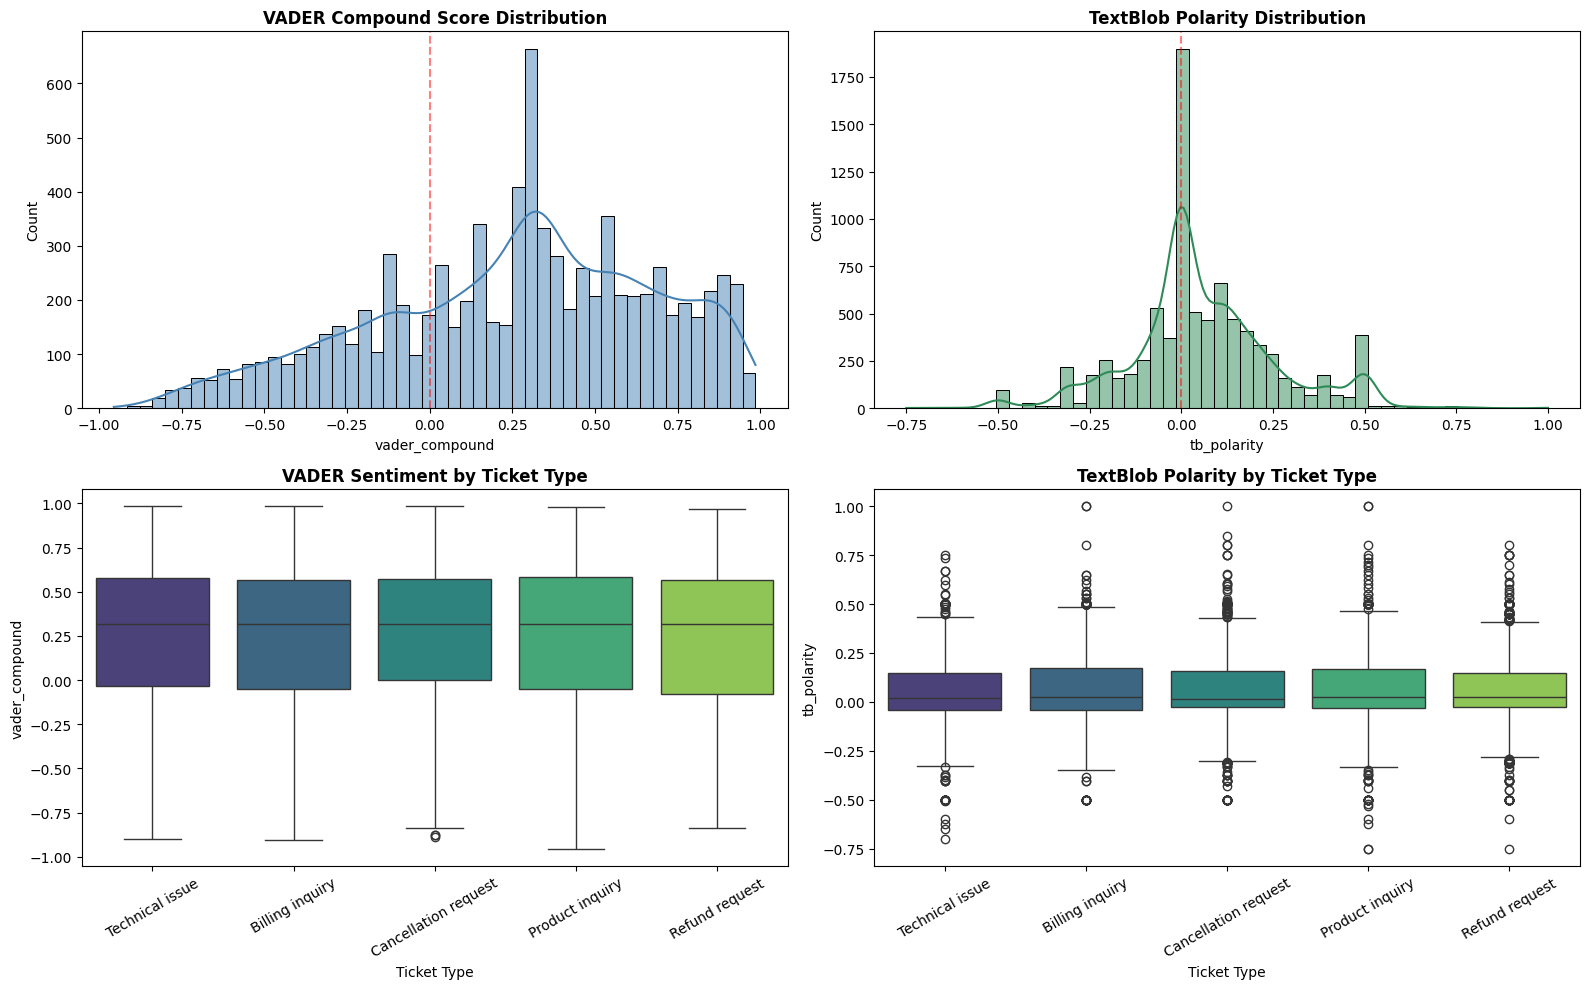

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sns.histplot(df['vader_compound'], bins=50, kde=True, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('VADER Compound Score Distribution', fontweight='bold')
axes[0,0].axvline(0, color='red', linestyle='--', alpha=0.5)
sns.histplot(df['tb_polarity'], bins=50, kde=True, ax=axes[0,1], color='seagreen')
axes[0,1].set_title('TextBlob Polarity Distribution', fontweight='bold')
axes[0,1].axvline(0, color='red', linestyle='--', alpha=0.5)
sns.boxplot(data=df, x='Ticket Type', y='vader_compound', ax=axes[1,0], palette='viridis')
axes[1,0].set_title('VADER Sentiment by Ticket Type', fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=30)
sns.boxplot(data=df, x='Ticket Type', y='tb_polarity', ax=axes[1,1], palette='viridis')
axes[1,1].set_title('TextBlob Polarity by Ticket Type', fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=30)
plt.tight_layout()

# Save figure
if not os.path.exists(figures_dir):
    os.makedirs(figures_dir, exist_ok=True)
plt.savefig(os.path.join(figures_dir, 'sentimentanalysis_sentiment_1.png'), dpi=300, bbox_inches='tight')
print(f"Saved figure: sentimentanalysis_sentiment_1.png")

plt.show()

Saved figure: sentimentanalysis_sentiment_2.png


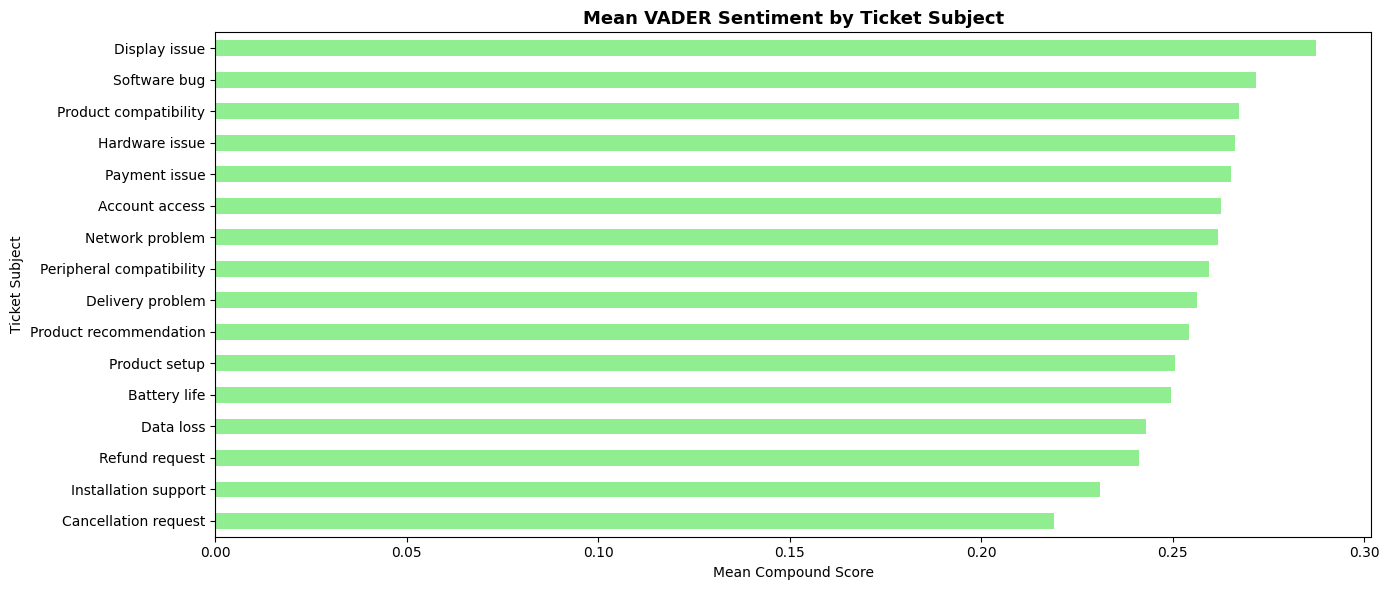

In [9]:
fig, ax = plt.subplots(figsize=(14, 6))
subject_sentiment = df.groupby('Ticket Subject')['vader_compound'].mean().sort_values()
subject_sentiment.plot(kind='barh', ax=ax, color=[
    'salmon' if v < -0.05 else ('lightgreen' if v > 0.05 else 'lightgray')
    for v in subject_sentiment.values])
ax.set_title('Mean VADER Sentiment by Ticket Subject', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Compound Score')
ax.axvline(0, color='black', linestyle='-', alpha=0.3)
plt.tight_layout()

# Save figure
if not os.path.exists(figures_dir):
    os.makedirs(figures_dir, exist_ok=True)
plt.savefig(os.path.join(figures_dir, 'sentimentanalysis_sentiment_2.png'), dpi=300, bbox_inches='tight')
print(f"Saved figure: sentimentanalysis_sentiment_2.png")

plt.show()

## Score Correlation Plot
Visual confirmation of the Pearson / Spearman correlation between VADER and TextBlob scores.

Saved figure: sentimentanalysis_sentiment_3.png


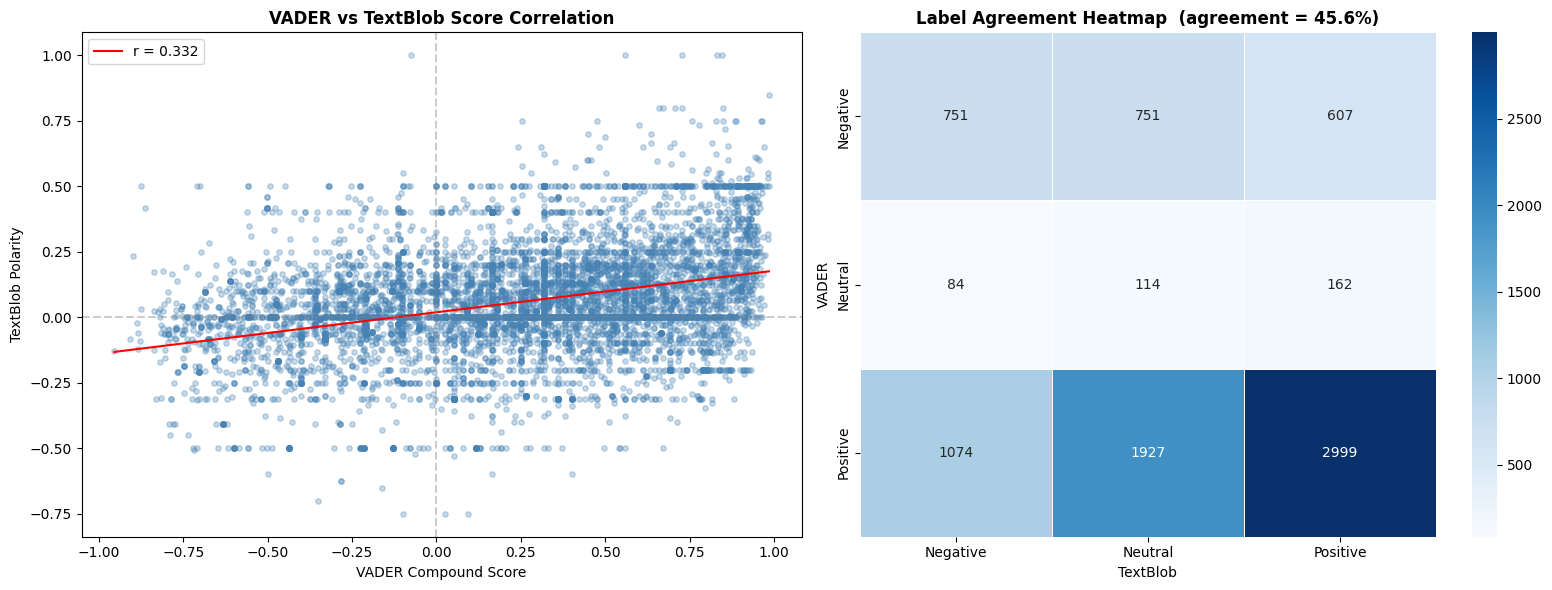

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter: VADER compound vs TextBlob polarity
axes[0].scatter(df['vader_compound'], df['tb_polarity'],
                alpha=0.3, s=15, color='steelblue')
m, b = np.polyfit(df['vader_compound'], df['tb_polarity'], 1)
x_line = np.linspace(df['vader_compound'].min(), df['vader_compound'].max(), 200)
axes[0].plot(x_line, m * x_line + b, color='red', linewidth=1.5, label=f'r = {pearson_r:.3f}')
axes[0].set_xlabel('VADER Compound Score')
axes[0].set_ylabel('TextBlob Polarity')
axes[0].set_title('VADER vs TextBlob Score Correlation', fontweight='bold')
axes[0].legend()
axes[0].axhline(0, color='grey', linestyle='--', alpha=0.4)
axes[0].axvline(0, color='grey', linestyle='--', alpha=0.4)

# Heatmap: label agreement crosstab
sns.heatmap(label_crosstab, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, ax=axes[1])
axes[1].set_title(
    f'Label Agreement Heatmap  (agreement = {label_agreement*100:.1f}%)',
    fontweight='bold')

plt.tight_layout()

# Save figure
if not os.path.exists(figures_dir):
    os.makedirs(figures_dir, exist_ok=True)
plt.savefig(os.path.join(figures_dir, 'sentimentanalysis_sentiment_3.png'), dpi=300, bbox_inches='tight')
print(f"Saved figure: sentimentanalysis_sentiment_3.png")

plt.show()